In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.metrics import mean_squared_error


In [58]:

INPUT_CSV = os.path.join("data", "used_cars_data.csv")
CLEAN_CSV = os.path.join("data", "used_cars_CLEAN.csv")

df0 = pd.read_csv(INPUT_CSV, sep=",", dtype={"dealer_zip": str})
print("df0:", df0.shape)


df1 = df0[df0["bed"].isna()]
print("df1:", df1.shape)

df2 = df1[df1["cabin"].isna()]
print("df2:", df2.shape)

df3 = df2[df2["frame_damaged"] != True]
print("df3:", df3.shape)

df4 = df3[df3["has_accidents"] != True]
print("df4:", df4.shape)

df5 = df4[df4["isCab"] != True]
print("df5:", df5.shape)

df6 = df5[~df5["main_picture_url"].isna()]
print("df6:", df6.shape)

df7 = df6[(df6["owner_count"].isna()) | (df6["owner_count"] == 1)]
print("df7:", df7.shape)

df8 = df7[df7["salvage"] != True]
print("df8:", df8.shape)

df9 = df8[df8["theft_title"] != True]
print("df9:", df9.shape)

df10 = df9[df9["daysonmarket"] < 365]
print("df10:", df10.shape)

drop_cols = [
    "bed", "bed_height", "cabin", "city", "dealer_zip",
    "description", "exterior_color", "has_accidents", "interior_color",
    "isCab", "frame_damaged", "latitude", "longitude", "main_picture_url", "owner_count",
    "is_certified", "is_cpo", "salvage", "savings_amount", "seller_rating", "sp_id", "theft_title",
    "vehicle_damage_category"
]

df11 = df10.drop(columns=[c for c in drop_cols if c in df10.columns])
print("df11 (clean):", df11.shape)

df11.to_csv(CLEAN_CSV, index=False)
print("Saved CLEAN dataset to:", CLEAN_CSV)

ModuleNotFoundError: No module named 'seaborn'

In [24]:
INPUT_CSV = os.path.join("data", "used_cars_CLEAN.csv")
MODEL_CSV = os.path.join("data", "used_cars_MODEL_50pct.csv") $

TARGET = "price"
MAX_MISSING = 0.40

df = pd.read_csv(INPUT_CSV, sep=",")
print("df:", df.shape)

essential_features = [
    TARGET,
    "year", "mileage",
    "horsepower", "engine_displacement",
    "engine_cylinders", "engine_type",
    "fuel_type", "fuel_tank_volume",
    "transmission", "transmission_display",
    "wheel_system", "wheel_system_display",
    "maximum_seating",
    "front_legroom", "back_legroom",
    "height", "length", "width", "wheelbase",
    "make_name", "model_name", "trim_name", "body_type",
    "listing_color",
    "major_options",
    "is_new",
]

existing = [c for c in essential_features if c in df.columns]
missing = [c for c in essential_features if c not in df.columns]
print("Missing essentials:", missing)

df_model = df[existing].copy()
print("df_model:", df_model.shape)

# Missing values policy
missing_rate = df_model.isna().mean().sort_values(ascending=False)
print("\nMissing rate:")
print(missing_rate)

to_drop = missing_rate[missing_rate > MAX_MISSING].index.tolist()
print("\nDropping columns (>40% NaN):", to_drop)

df_model2 = df_model.drop(columns=to_drop)

num_cols = df_model2.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in df_model2.columns if c not in num_cols]

# Don't impute target if numeric
num_cols_no_target = [c for c in num_cols if c != TARGET]

if num_cols_no_target:
    df_model2[num_cols_no_target] = df_model2[num_cols_no_target].fillna(
        df_model2[num_cols_no_target].median(numeric_only=True)
    )

if cat_cols:
    df_model2[cat_cols] = df_model2[cat_cols].fillna("Unknown")

print("df_model2:", df_model2.shape)

# Keep 50% random sample
df_final = df_model2.sample(frac=0.5, random_state=42)
print("df_final (50%):", df_final.shape)

# Save final model dataset
df_final.to_csv(MODEL_CSV, index=False)
print("Saved MODEL dataset to:", MODEL_CSV)

SyntaxError: invalid syntax (3494470967.py, line 2)

In [25]:
df_final=pd.read_csv("data/used_cars_MODEL_50pct.csv")

In [26]:
print("Shape :", df_final.shape)
print("\nTypes :")
print(df_final.dtypes.value_counts())
print("\nColonnes :")
print(df_final.columns.tolist())

Shape : (907164, 27)

Types :
str        21
float64     4
int64       1
bool        1
Name: count, dtype: int64

Colonnes :
['price', 'year', 'mileage', 'horsepower', 'engine_displacement', 'engine_cylinders', 'engine_type', 'fuel_type', 'fuel_tank_volume', 'transmission', 'transmission_display', 'wheel_system', 'wheel_system_display', 'maximum_seating', 'front_legroom', 'back_legroom', 'height', 'length', 'width', 'wheelbase', 'make_name', 'model_name', 'trim_name', 'body_type', 'listing_color', 'major_options', 'is_new']


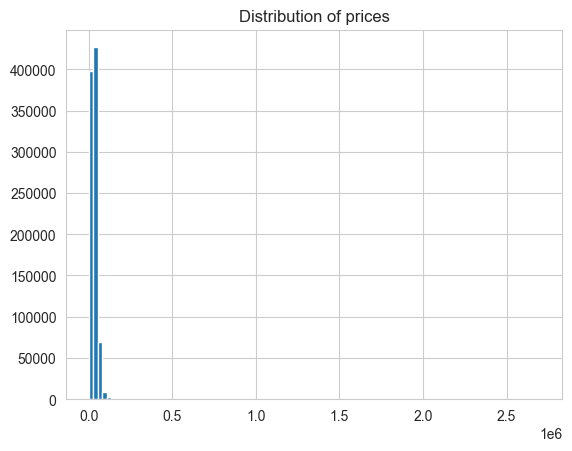

In [27]:
plt.hist(df_final["price"], bins=100)
plt.title("Distribution of prices")
plt.show()

In [ ]:
#On remarque ici que les voitures  luciexieuses prennent bq trop de places, valeurs abérrantes

In [29]:
print(df_final["price"].describe())
print(df_final["price"].sort_values(ascending=False).head(10)) #véirification

count    9.071640e+05
mean     3.327334e+04
std      1.878425e+04
min      2.990000e+02
25%      2.199000e+04
50%      2.913500e+04
75%      4.098800e+04
max      2.698500e+06
Name: price, dtype: float64
240534    2698500.0
892023    2000000.0
446411    1390000.0
231800    1385900.0
704489    1299950.0
225745    1100000.0
602371    1100000.0
686133     999900.0
582508     999800.0
656765     999800.0
Name: price, dtype: float64


In [30]:
df_final = df_final[(df_final["price"] >= 3000) & (df_final["price"] <= 150000)]
print(df_final.shape) # on enleve donc ici les voitures trop luxieuses

(905105, 27)


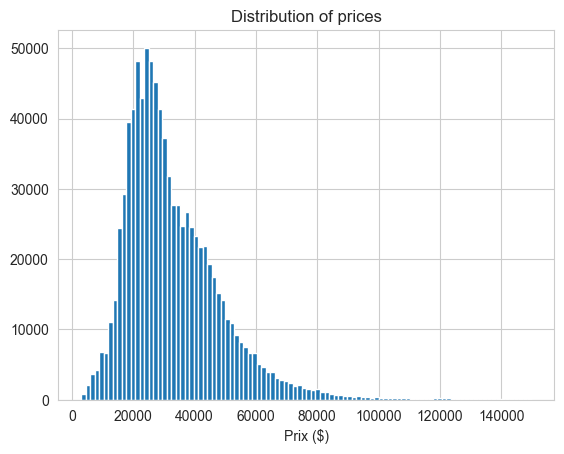

In [31]:
plt.hist(df_final["price"], bins=100)
plt.title("Distribution of prices")
plt.xlabel("Prix ($)")
plt.show()

In [ ]:
# On observe que la distribution du prix est asymétrique à droite
##ce qui correspnd bien au marché classique de l'occasion.
#donc pourrait traivailler avec le log des prix

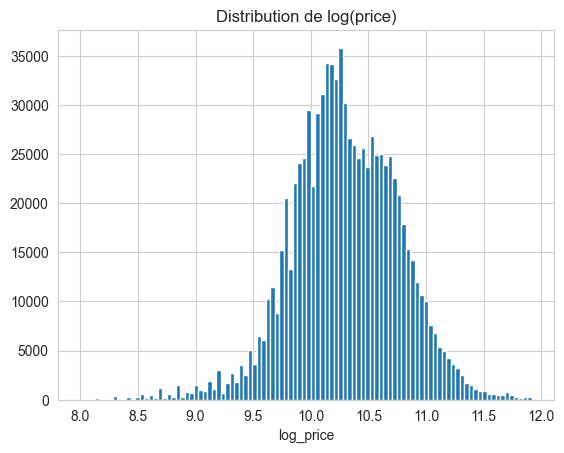

In [32]:

df_final["log_price"] = np.log(df_final["price"])

plt.hist(df_final["log_price"], bins=100)
plt.title("Distribution de log(price)")
plt.xlabel("log_price")
plt.show()

In [33]:
df_final[["mileage", "horsepower", "year"]].describe()

,mileage,horsepower,year
count,9.051050e+05,905105.000000,905105.000000
mean,1.428748e+04,245.417739,2018.883661
std,2.830737e+04,87.244820,3.088183
min,0.000000e+00,69.000000,1915.000000
25%,5.000000e+00,175.000000,2018.000000
50%,1.200000e+01,240.000000,2020.000000
75%,2.030400e+04,295.000000,2020.000000
max,1.111111e+06,808.000000,2021.000000


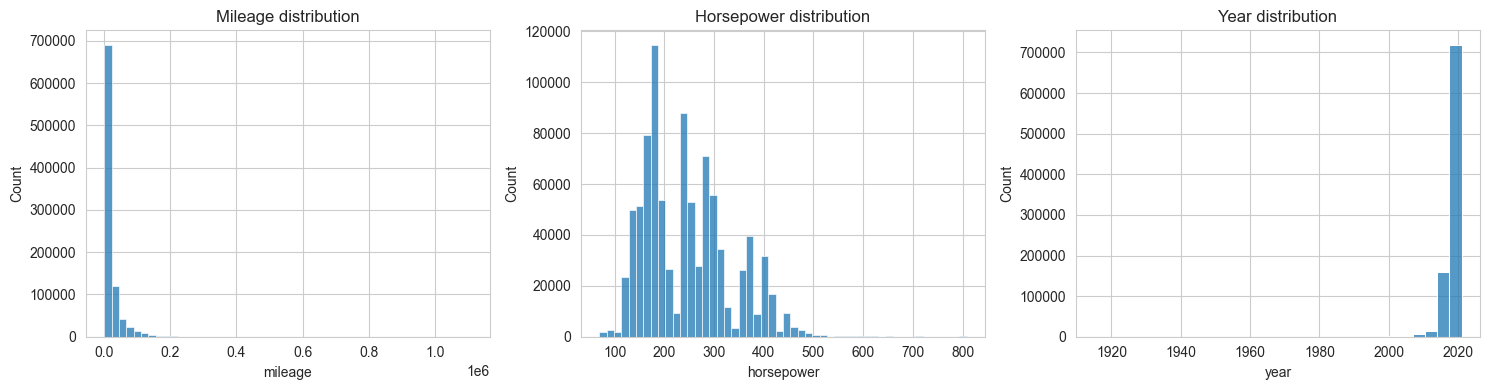

In [34]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.histplot(df_final["mileage"], bins=50, ax=axes[0])
axes[0].set_title("Mileage distribution")

sns.histplot(df_final["horsepower"], bins=50, ax=axes[1])
axes[1].set_title("Horsepower distribution")

sns.histplot(df_final["year"], bins=30, ax=axes[2])
axes[2].set_title("Year distribution")

plt.tight_layout()
plt.show()

In [35]:
df_final[["price", "mileage", "horsepower", "year"]].describe().T

,count,mean,std,min,25%,50%,75%,max
price,905105.0,32920.276848,15916.591499,3000.0,21990.0,29095.0,40900.0,150000.0
mileage,905105.0,14287.481085,28307.372218,0.0,5.0,12.0,20304.0,1111111.0
horsepower,905105.0,245.417739,87.244820,69.0,175.0,240.0,295.0,808.0
year,905105.0,2018.883661,3.088183,1915.0,2018.0,2020.0,2020.0,2021.0


In [36]:
df_final.sort_values("year").head(10)

,price,year,mileage,horsepower,engine_displacement,engine_cylinders,engine_type,fuel_type,fuel_tank_volume,transmission,...,width,wheelbase,make_name,model_name,trim_name,body_type,listing_color,major_options,is_new,log_price
377608,9900.0,1915,500.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,M,...,Unknown,Unknown,Ford,Model T,Unknown,Unknown,BLUE,Unknown,False,9.200290
127022,11900.0,1915,500.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,M,...,Unknown,Unknown,Ford,Model T,Unknown,Unknown,RED,Unknown,False,9.384294
651709,18500.0,1915,12.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,M,...,Unknown,Unknown,Ford,Model T,Unknown,Unknown,RED,Unknown,False,9.825526
592234,14995.0,1923,12.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,Unknown,...,Unknown,Unknown,Ford,Model T,Dragster,Convertible,BLACK,['Navigation System'],False,9.615472
693024,13995.0,1923,12.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,Unknown,...,Unknown,Unknown,Ford,Model T,Dragster,Convertible,RED,Unknown,False,9.546455
544159,10995.0,1923,12.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,Unknown,...,Unknown,Unknown,Ford,Model T,Dragster,Convertible,UNKNOWN,Unknown,False,9.305196
593513,16900.0,1924,12.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,M,...,Unknown,Unknown,Ford,Model T,Unknown,Unknown,BLACK,Unknown,False,9.735069
428492,11500.0,1925,12.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,M,...,Unknown,Unknown,Ford,Model T,Unknown,Unknown,BLACK,Unknown,False,9.350102
131724,21000.0,1926,12.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,A,...,Unknown,Unknown,Ford,Model T,Unknown,Unknown,BLUE,Unknown,False,9.952278
584811,7995.0,1926,4538.0,240.0,2500.0,Unknown,Unknown,Unknown,Unknown,M,...,Unknown,Unknown,Ford,Model T,Unknown,Unknown,GRAY,Unknown,False,8.986572


In [37]:
df_final = df_final[df_final["year"] >= 1990]

In [38]:
df_final["year"].describe()


count    903571.000000
mean       2018.971778
std           2.171857
min        1990.000000
25%        2018.000000
50%        2020.000000
75%        2020.000000
max        2021.000000
Name: year, dtype: float64

In [39]:
df_final["age"] = 2025 - df_final["year"]
df_final["age"].describe()

count    903571.000000
mean          6.028222
std           2.171857
min           4.000000
25%           5.000000
50%           5.000000
75%           7.000000
max          35.000000
Name: age, dtype: float64

In [ ]:
# age moyen ici cest 6 ans, bonne info

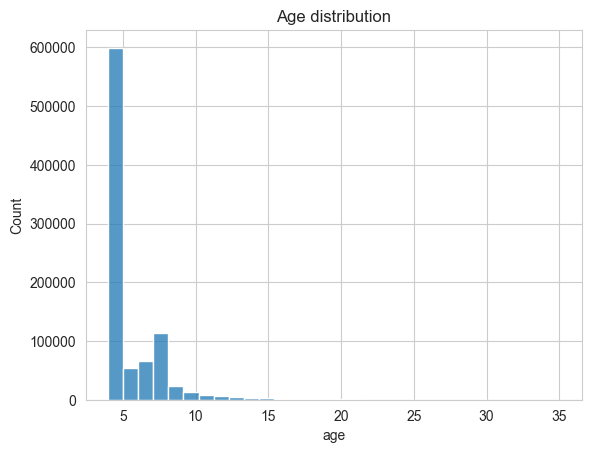

In [40]:
sns.histplot(df_final["age"], bins=30)
plt.title("Age distribution")
plt.show()

In [ ]:
#ici asymétrique à droite forte concentraitoion à droite

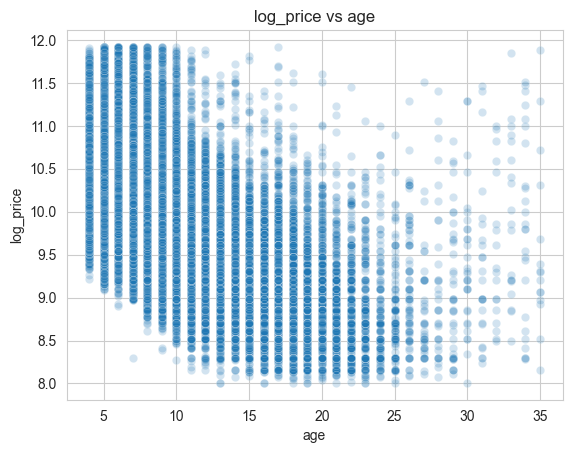

In [41]:
sns.scatterplot(data=df_final, x="age", y="log_price", alpha=0.2)
plt.title("log_price vs age")
plt.show()

In [ ]:
# on voit ici quand l'age augmente le prix baisse relation neagtive ce qui pararit éncoomqiuement cohérent

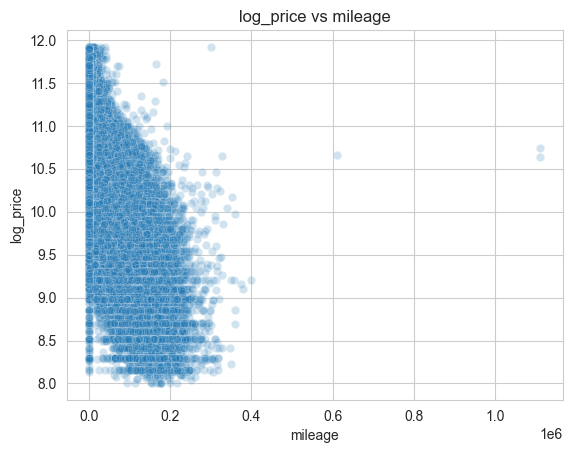

In [42]:
sns.scatterplot(data=df_final, x="mileage", y="log_price", alpha=0.2)
plt.title("log_price vs mileage")
plt.show()

In [ ]:
# relation négative donc plus le kilométrage augmente  plus le prix baisse

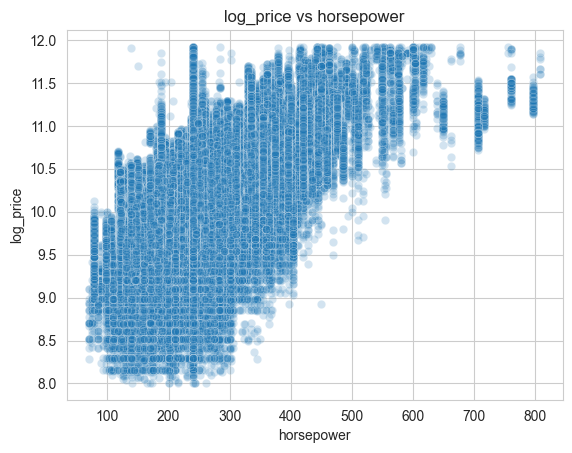

In [43]:
sns.scatterplot(data=df_final, x="horsepower", y="log_price", alpha=0.2)
plt.title("log_price vs horsepower")
plt.show()

In [ ]:
#plus la voiture est puissante plus le prix augmente

In [44]:
df_final[["log_price","age","mileage","horsepower"]].corr()

,log_price,age,mileage,horsepower
log_price,1.000000,-0.531323,-0.513829,0.664301
age,-0.531323,1.000000,0.836265,-0.006321
mileage,-0.513829,0.836265,1.000000,0.006364
horsepower,0.664301,-0.006321,0.006364,1.000000


In [45]:
df_final.select_dtypes(include=["int64","float64"]).corr()

,price,year,mileage,horsepower,engine_displacement,log_price,age
price,1.000000,0.374806,-0.368095,0.685012,0.481336,0.937646,-0.374806
year,0.374806,1.000000,-0.836265,0.006321,-0.072860,0.531323,-1.000000
mileage,-0.368095,-0.836265,1.000000,0.006364,0.089053,-0.513829,0.836265
horsepower,0.685012,0.006321,0.006364,1.000000,0.833531,0.664301,-0.006321
engine_displacement,0.481336,-0.072860,0.089053,0.833531,1.000000,0.465873,0.072860
log_price,0.937646,0.531323,-0.513829,0.664301,0.465873,1.000000,-0.531323
age,-0.374806,-1.000000,0.836265,-0.006321,0.072860,-0.531323,1.000000


In [47]:
num_cols = df_final.select_dtypes(include=["int64","float64"]).columns
cat_cols = df_final.select_dtypes(include=["object","bool"]).columns

print("numériques :", num_cols)
print("catégorielles :", cat_cols)

numériques : Index(['price', 'year', 'mileage', 'horsepower', 'engine_displacement',
       'log_price', 'age'],
      dtype='str')
catégorielles : Index(['engine_cylinders', 'engine_type', 'fuel_type', 'fuel_tank_volume',
       'transmission', 'transmission_display', 'wheel_system',
       'wheel_system_display', 'maximum_seating', 'front_legroom',
       'back_legroom', 'height', 'length', 'width', 'wheelbase', 'make_name',
       'model_name', 'trim_name', 'body_type', 'listing_color',
       'major_options', 'is_new'],
      dtype='str')


/var/folders/zr/jh4jk1xd53d04qg98gjzpmxc0000gn/T/ipykernel_1742/3117347985.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_final.select_dtypes(include=["object","bool"]).columns


In [48]:
df_final[cat_cols].nunique().sort_values(ascending=False)

major_options           115624
trim_name                 5373
model_name                 898
length                     747
height                     434
wheelbase                  421
width                      261
back_legroom               193
fuel_tank_volume           164
front_legroom               83
make_name                   59
transmission_display        37
engine_cylinders            34
engine_type                 34
listing_color               15
maximum_seating             13
body_type                   10
fuel_type                    9
wheel_system_display         6
wheel_system                 6
transmission                 5
is_new                       2
dtype: int64

In [ ]:
#Certaines variables ont trop de catégories

In [49]:
df_final = df_final.drop(columns=["major_options", "trim_name"])

In [50]:
df_final.shape

(903571, 27)

In [52]:
df_final = df_final.drop(columns=["price","year"])

In [ ]:
# on eleve price car on a deja log et on enleve pour eviter la mutlicolinéarité entre age et year ( corr de -1)

In [53]:
df_final.columns

Index(['mileage', 'horsepower', 'engine_displacement', 'engine_cylinders',
       'engine_type', 'fuel_type', 'fuel_tank_volume', 'transmission',
       'transmission_display', 'wheel_system', 'wheel_system_display',
       'maximum_seating', 'front_legroom', 'back_legroom', 'height', 'length',
       'width', 'wheelbase', 'make_name', 'model_name', 'body_type',
       'listing_color', 'is_new', 'log_price', 'age'],
      dtype='str')

In [ ]:
##On va maintenant regarder les premières valeurs des colonnes qui semblent être des nombres stockés en texte

In [54]:
df_final[[
    "fuel_tank_volume",
    "maximum_seating",
    "front_legroom",
    "back_legroom",
    "height",
    "length",
    "width",
    "wheelbase"
]].head(10)

,fuel_tank_volume,maximum_seating,front_legroom,back_legroom,height,length,width,wheelbase
0,18.8 gal,7 seats,44.1 in,39.4 in,66.5 in,187.4 in,74.4 in,109.4 in
1,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
2,21.5 gal,5 seats,41.2 in,38.3 in,73.6 in,188.4 in,73.8 in,118.4 in
3,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
4,18.5 gal,5 seats,42.2 in,33.1 in,56.4 in,191 in,72.8 in,107.9 in
5,23 gal,6 seats,40.9 in,35.6 in,77.7 in,228.9 in,82.1 in,140.5 in
6,13 gal,5 seats,42.2 in,34.6 in,56.5 in,176.7 in,69 in,106.3 in
7,12.4 gal,5 seats,44 in,37.4 in,57 in,182.7 in,71.5 in,106.8 in
8,19.5 gal,7 seats,42.2 in,41.7 in,68.6 in,200.6 in,77.2 in,114.2 in
9,18.5 gal,5 seats,42.6 in,40.6 in,68.3 in,188.8 in,85.8 in,112.2 in


In [ ]:
#On transforme toutes ces colonnes en nombres

In [55]:
cols_units = [
    "fuel_tank_volume",
    "maximum_seating",
    "front_legroom",
    "back_legroom",
    "height",
    "length",
    "width",
    "wheelbase"
]

for c in cols_units:
    df_final[c] = (
        df_final[c]
        .astype(str)
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )

In [56]:
df_final[cols_units].head()

,fuel_tank_volume,maximum_seating,front_legroom,back_legroom,height,length,width,wheelbase
0,18.8,7.0,44.1,39.4,66.5,187.4,74.4,109.4
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21.5,5.0,41.2,38.3,73.6,188.4,73.8,118.4
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18.5,5.0,42.2,33.1,56.4,191.0,72.8,107.9


In [57]:
df_final.isna().mean().sort_values(ascending=False)

back_legroom            0.075279
front_legroom           0.053896
fuel_tank_volume        0.049433
maximum_seating         0.049362
height                  0.049360
width                   0.049359
length                  0.049359
wheelbase               0.049350
log_price               0.000000
is_new                  0.000000
listing_color           0.000000
body_type               0.000000
model_name              0.000000
make_name               0.000000
mileage                 0.000000
horsepower              0.000000
wheel_system_display    0.000000
wheel_system            0.000000
transmission_display    0.000000
transmission            0.000000
fuel_type               0.000000
engine_type             0.000000
engine_cylinders        0.000000
engine_displacement     0.000000
age                     0.000000
dtype: float64

In [ ]:
# On prépare maintenant les variables X et y

In [58]:
X = df_final.drop(columns=["log_price"])
y = df_final["log_price"]

In [59]:
X.shape, y.shape

((903571, 24), (903571,))

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [61]:
X_train.shape, X_test.shape

((722856, 24), (180715, 24))

In [63]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object","bool"]).columns

print("numériques :", num_cols)
print("catégorielles :", cat_cols)

numériques : Index(['mileage', 'horsepower', 'engine_displacement', 'fuel_tank_volume',
       'maximum_seating', 'front_legroom', 'back_legroom', 'height', 'length',
       'width', 'wheelbase', 'age'],
      dtype='str')
catégorielles : Index(['engine_cylinders', 'engine_type', 'fuel_type', 'transmission',
       'transmission_display', 'wheel_system', 'wheel_system_display',
       'make_name', 'model_name', 'body_type', 'listing_color', 'is_new'],
      dtype='str')


/var/folders/zr/jh4jk1xd53d04qg98gjzpmxc0000gn/T/ipykernel_1742/2385152613.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object","bool"]).columns


In [64]:

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [65]:
numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

In [66]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [67]:
categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation.

In [68]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [69]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [70]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

ValueError: Cannot use most_frequent strategy with non-numeric data:
could not convert string to float: 'V6'

In [71]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [72]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [73]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

ValueError: Cannot use constant strategy with non-numeric data:
could not convert string to float: 'V6'

In [74]:
categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [75]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [76]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

In [77]:
X_train_prepared.shape, X_test_prepared.shape

((722856, 1105), (180715, 1105))

In [78]:
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
sum(len(c) for c in ohe.categories_)

1093

In [79]:
for col, cats in zip(cat_cols, ohe.categories_):
    print(col, ":", len(cats))

engine_cylinders : 34
engine_type : 34
fuel_type : 9
transmission : 5
transmission_display : 37
wheel_system : 6
wheel_system_display : 6
make_name : 59
model_name : 876
body_type : 10
listing_color : 15
is_new : 2


In [81]:
X_train = X_train.drop(columns=["model_name"])
X_test = X_test.drop(columns=["model_name"])

KeyError: "['model_name'] not found in axis"

In [83]:
X_train.columns

Index(['mileage', 'horsepower', 'engine_displacement', 'engine_cylinders',
       'engine_type', 'fuel_type', 'fuel_tank_volume', 'transmission',
       'transmission_display', 'wheel_system', 'wheel_system_display',
       'maximum_seating', 'front_legroom', 'back_legroom', 'height', 'length',
       'width', 'wheelbase', 'make_name', 'body_type', 'listing_color',
       'is_new', 'age'],
      dtype='str')

In [84]:
model = LinearRegression()
model.fit(X_train_prepared, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [86]:
y_pred = model.predict(X_test_prepared)

In [90]:
y_pred[:10]

array([10.64847886, 10.29237915, 11.0773473 , 10.74256479, 10.30628448,
       10.62553433, 10.72097279,  9.6277655 , 10.3091164 , 11.53207073])

In [92]:
rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse

TypeError: got an unexpected keyword argument 'squared'

In [93]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

rmse

np.float64(0.13564825030592453)

In [94]:
r2 = r2_score(y_test, y_pred)
r2

0.9151254702205924

In [95]:
price_pred = np.exp(y_pred)
price_true = np.exp(y_test)

rmse_price = np.sqrt(((price_true - price_pred) ** 2).mean())
rmse_price

np.float64(4980.4523745357665)

In [96]:
import pandas as pd

results = pd.DataFrame({
    "real_price": np.exp(y_test[:10]),
    "predicted_price": np.exp(y_pred[:10])
})

results

,real_price,predicted_price
634734,37717.0,42128.462588
227546,26830.0,29506.892239
782618,67680.0,64689.054916
306982,41970.0,46284.610318
850010,36497.0,29920.061340
53193,37115.0,41172.849586
151422,37800.0,45295.945047
704455,14800.0,15180.477421
565429,31175.0,30004.912484
497933,76995.0,101932.970891


In [ ]:
# Dans ce projet, nous avons construit un
modèle de prédiction des prix automobiles à partir 
de caractéristiques telles que le kilométrage, la puissance, 
les spécifications du moteur et le type de véhicule. Après le n
ettoyage des données et la préparation des variables, nous avons
entraîné un modèle de régression linéaire à l'aide d'un pipeline 
de prétraitement.

#Le modèle présente de bonnes performances, avec un coefficient
 de détermination (R²) d'environ 0,91 et une erreur quadratique 
 moyenne (RMSE) d'environ 5 000 $, ce qui signifie qu'il explique la majeure partie de la variabilité des prix et prédit les prix avec une erreur moyenne raisonnable par rapport au prix moyen de l'ensemble de données.

#Globalement, les résultats montrent que les caractéristiques sélectionnées expliquent une grande partie de la variation des prix, même si les prédictions restent moins précises pour les véhicules très chers.